In [12]:
import os
import random
import numpy as np
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Import common utilities from HTB Evasion Library
from htb_ai_library import (
    set_reproducibility,
    SimpleCNN,
    get_mnist_loaders,
    mnist_denormalize,
    train_model,
    evaluate_accuracy
)

# Configure reproducibility
set_reproducibility(1337)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [13]:
# Prepare data loaders using library function (normalized space)
train_loader, test_loader = get_mnist_loaders(batch_size=128, normalize=True)

# Initialize model using library's SimpleCNN
model = SimpleCNN().to(device)


# Train the model using library function
trained_model = train_model(model, train_loader, test_loader, epochs=1, device=device)

# Evaluate baseline accuracy using library function
baseline_acc = evaluate_accuracy(trained_model, test_loader, device)
print(f"Baseline test accuracy: {baseline_acc:.2f}%")

Epoch 1/1: Avg Loss = 0.1567, Test Accuracy = 98.37%
Baseline test accuracy: 98.37%


In [26]:
####################################################################################################
#RUNS MODEL IN SAFE EVALUATION MODE AND COMPUTES PREDICTION AND LOSS NEEDED FOR ADVERSERIAL GRADIENT
####################################################################################################


def _forward_and_loss(model: nn.Module, x: Tensor, y: Tensor) -> tuple[Tensor, Tensor]:
    """Forward pass and cross-entropy loss without side effects.

    Args:
        model: Neural network classifier
        x: Input images tensor
        y: Target labels tensor

    Returns:
        tuple[Tensor, Tensor]: Model logits and scalar loss value
    """
    if getattr(model, "training", False):
        raise RuntimeError("Expected model.eval() for attack computations to avoid BN/Dropout state updates")
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    return logits, loss

In [27]:
#####################################################
# CACULATES GRADIENT OF LOSS WITH RESPECT TO AN IMAGE
#####################################################

def _input_gradient(model: nn.Module, x: Tensor, y: Tensor) -> Tensor:
    """Return gradient of loss with respect to input tensor x.

    Args:
        model: Neural network in evaluation mode
        x: Input images to compute gradients for
        y: True labels for loss computation

    Returns:
        Tensor: Gradient tensor with same shape as x
    """
    x_req = x.clone().detach().requires_grad_(True)
    _, loss = _forward_and_loss(model, x_req, y)
    model.zero_grad(set_to_none=True)
    loss.backward()
    return x_req.grad.detach()


In [28]:
######################################
# CORE IMPLEMENTATION
######################################

def fgsm_attack(model: nn.Module,
                images: Tensor,
                labels: Tensor,
                epsilon: float,
                targeted: bool = False) -> Tensor:

    # Valid normalized range for MNIST
    MNIST_NORM_MIN = (0.0 - 0.1307) / 0.3081
    MNIST_NORM_MAX = (1.0 - 0.1307) / 0.3081

    if epsilon < 0:
        raise ValueError("epsilon must be non-negative")
    if not images.is_floating_point():
        raise ValueError("images must be floating point tensors")
    # Gets input gradients
    grad = _input_gradient(model, images, labels)
    # Chooses attack type ie Targetted or Untargetted
    step_dir = -1.0 if targeted else 1.0
    # Creates adversarial image
    x_adv = images + step_dir * epsilon * grad.sign()
    # Normalizes Adverserial image
    x_adv = torch.clamp(x_adv, MNIST_NORM_MIN, MNIST_NORM_MAX)
    return x_adv.detach()


In [29]:
#########################################################
# Pixel Space Varient OF FGSM
#########################################################

# This function turns the mean and std lists into tensors shaped so they can be broadcast across every pixel in every image
# Helper Fuction so that pytorch can apply normalization channels without errors.
def _norm_params(images: Tensor, mean: list, std: list) -> tuple[Tensor, Tensor]:
    """Convert normalization parameters to broadcastable tensors.

    Args:
        images: Input images tensor with shape (N, C, H, W)
        mean: Normalization mean per channel as list
        std: Normalization std per channel as list

    Returns:
        tuple[Tensor, Tensor]: Mean and std tensors with shape (1, C, 1, 1)
    """
    device, dtype, C = images.device, images.dtype, images.shape[1]
    mean_t = torch.tensor(mean, device=device, dtype=dtype).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=device, dtype=dtype).view(1, -1, 1, 1)
    if mean_t.shape[1] != C or std_t.shape[1] != C:
        raise ValueError("mean/std channels must match images")
    return mean_t, std_t





def fgsm_pixel_space(model: nn.Module,
                     images: Tensor,
                     labels: Tensor,
                     epsilon: float,
                     mean: list,
                     std: list,
                     targeted: bool = False) -> Tensor:
    """FGSM for pixel-space inputs attacking normalized models.

    This variant accepts images in [0,1] pixel space rather than normalized
    space. It normalizes inputs internally for the model, converts gradients
    back to pixel space, and returns adversarials in [0,1] pixel space.

    Args:
        model: Model expecting normalized inputs
        images: Clean images in [0,1] pixel space (unnormalized)
        labels: Target labels
        epsilon: Max perturbation in pixel space (e.g., 8/255)
        mean: Normalization mean per channel
        std: Normalization std per channel
        targeted: If True, minimize loss towards labels

    Returns:
        Tensor: Adversarial images in [0,1] pixel space (unnormalized)
    """
    mean_t, std_t = _norm_params(images, mean, std)
    x = images.clone().detach()
    x_norm = (x - mean_t) / std_t
    x_norm.requires_grad_(True)

    _, loss = _forward_and_loss(model, x_norm, labels)
    model.zero_grad(set_to_none=True)
    loss.backward()

    # Convert gradient from normalized space to image space
    grad_img = x_norm.grad / std_t
    step_dir = -1.0 if targeted else 1.0
    x_adv = torch.clamp(x + step_dir * epsilon * grad_img.sign(), 0.0, 1.0)
    return x_adv.detach()

    

In [30]:
###################################
# EVALUATION
###################################


def iterative_fgsm(model: nn.Module,
                   images: Tensor,
                   labels: Tensor,
                   epsilon: float,
                   num_iter: int,
                   alpha: float | None = None,
                   targeted: bool = False,
                   random_start: bool = False) -> Tensor:
    """Iterative FGSM (Basic Iterative Method) with projection.

    Args:
        model: Target classifier in evaluation mode
        images: Clean images (normalized)
        labels: Ground-truth or target labels
        epsilon: L_infinity budget (in normalized space)
        num_iter: Number of iterations
        alpha: Step size per iteration (defaults to epsilon/T)
        targeted: If True, targeted attack
        random_start: If True, initialize within the epsilon ball

    Returns:
        Tensor: Adversarial images (normalized)
    """
    # Valid normalized range for MNIST
    MNIST_NORM_MIN = (0.0 - 0.1307) / 0.3081
    MNIST_NORM_MAX = (1.0 - 0.1307) / 0.3081

    if alpha is None:
        alpha = epsilon / max(num_iter, 1)
    if random_start:
        torch.manual_seed(1337)
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(images + delta, MNIST_NORM_MIN, MNIST_NORM_MAX)
    else:
        x_adv = images.clone()

    for _ in range(num_iter):
        x_adv = x_adv.detach().requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, labels)
        model.zero_grad(set_to_none=True)
        loss.backward()
        step_dir = -1.0 if targeted else 1.0
        x_adv = x_adv + step_dir * alpha * x_adv.grad.sign()
        x_adv = torch.clamp(images + (x_adv - images).clamp(-epsilon, epsilon), MNIST_NORM_MIN, MNIST_NORM_MAX)

    return x_adv.detach()



In [37]:
###################################
# VISUALIZATION
###################################


import matplotlib.pyplot as plt
import numpy as np

# Colors imported from library
from htb_ai_library import (
    HTB_GREEN, NODE_BLACK, HACKER_GREY, WHITE,
    AZURE, NUGGET_YELLOW, MALWARE_RED, VIVID_PURPLE, AQUAMARINE
)

def _style_axes(ax: plt.Axes) -> None:
    """Apply Hack The Box dark theme to an axes instance.

    Args:
        ax: Matplotlib axes to style
    """
    ax.set_facecolor(NODE_BLACK)
    ax.tick_params(colors=HACKER_GREY)
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
    ax.grid(True, color=HACKER_GREY, linestyle="--", alpha=0.25)

def visualize_ifgsm(model: nn.Module,
                    image: Tensor,
                    label: Tensor,
                    epsilon: float,
                    num_iter: int,
                    targeted: bool = False,
                    target_class: int | None = None) -> None:
    """Wrapper for visualize_attack using I-FGSM.

    Args:
        model: Classifier model
        image: Single image tensor [C,H,W]
        label: True label
        epsilon: Perturbation budget
        num_iter: Number of iterations
        targeted: If True, targeted attack
        target_class: Target class for targeted attacks
    """
    alpha = epsilon / max(num_iter, 1)

    def _make_adv(m, xb, yb):
        y_used = yb if not targeted else torch.full_like(yb, target_class)
        return iterative_fgsm(
            m, xb, y_used,
            epsilon, num_iter, alpha,
            targeted=targeted,
            random_start=True
        )

    mode = "Targeted" if targeted else "Untargeted"
    visualize_attack(
        model, image, label, _make_adv,
        title=f"I-FGSM {mode}",
        targeted=targeted,
        target_class=target_class
    )



I-FGSM flips (first batch): 99.22%
clean_accuracy: 1.0000
adversarial_accuracy: 0.0078
attack_success_rate: 0.9922
avg_clean_confidence: 0.9852
avg_adv_confidence: 0.0120
avg_confidence_drop: 0.9732
avg_l2_perturbation: 14.0667
max_linf_perturbation: 0.8000


/tmp/ipykernel_5940/3348737688.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.93))


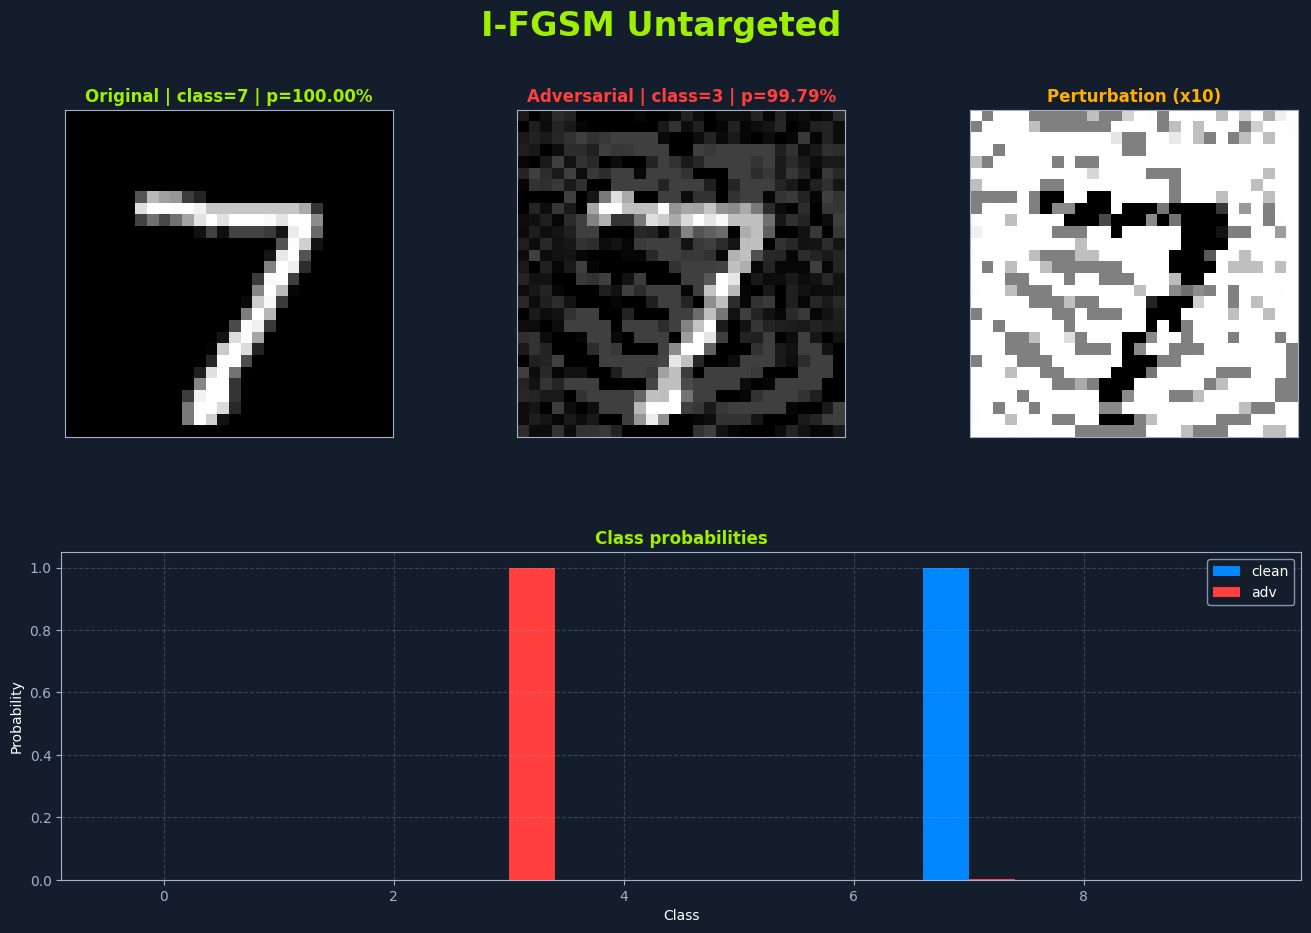

In [38]:
##########################################
# Testing Iterative FGSM
##########################################
# Assume model, test_loader, device from FGSM Setup
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

epsilon = 0.8
num_iter = 10
alpha = epsilon / num_iter  # alpha = 0.08

with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

x_adv_ifgsm = iterative_fgsm(
    model, images, labels,
    epsilon=epsilon,
    num_iter=num_iter,
    alpha=alpha,
    targeted=False,
    random_start=True
)

with torch.no_grad():
    adv_pred_ifgsm = model(x_adv_ifgsm).argmax(dim=1)

originally_correct = clean_pred == labels
flipped_ifgsm = (adv_pred_ifgsm != labels) & originally_correct
print(
    f"I-FGSM flips (first batch): "
    f"{(flipped_ifgsm.float().sum() / originally_correct.float().sum().clamp_min(1.0)).item():.2%}"
)


# Reuse evaluate_attack function from the Evaluation Metrics section
metrics_ifgsm = evaluate_attack(model, images, x_adv_ifgsm, labels)
for k, v in metrics_ifgsm.items():
    print(f"{k}: {v:.4f}")






# Visualize first sample from test batch
_ = visualize_ifgsm(
    model,
    images[0].detach().cpu(),
    labels[0].detach().cpu(),
    epsilon,
    num_iter,
    targeted=False
)


epsilon=0.50 -> predicted 7


/tmp/ipykernel_5940/3348737688.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.93))


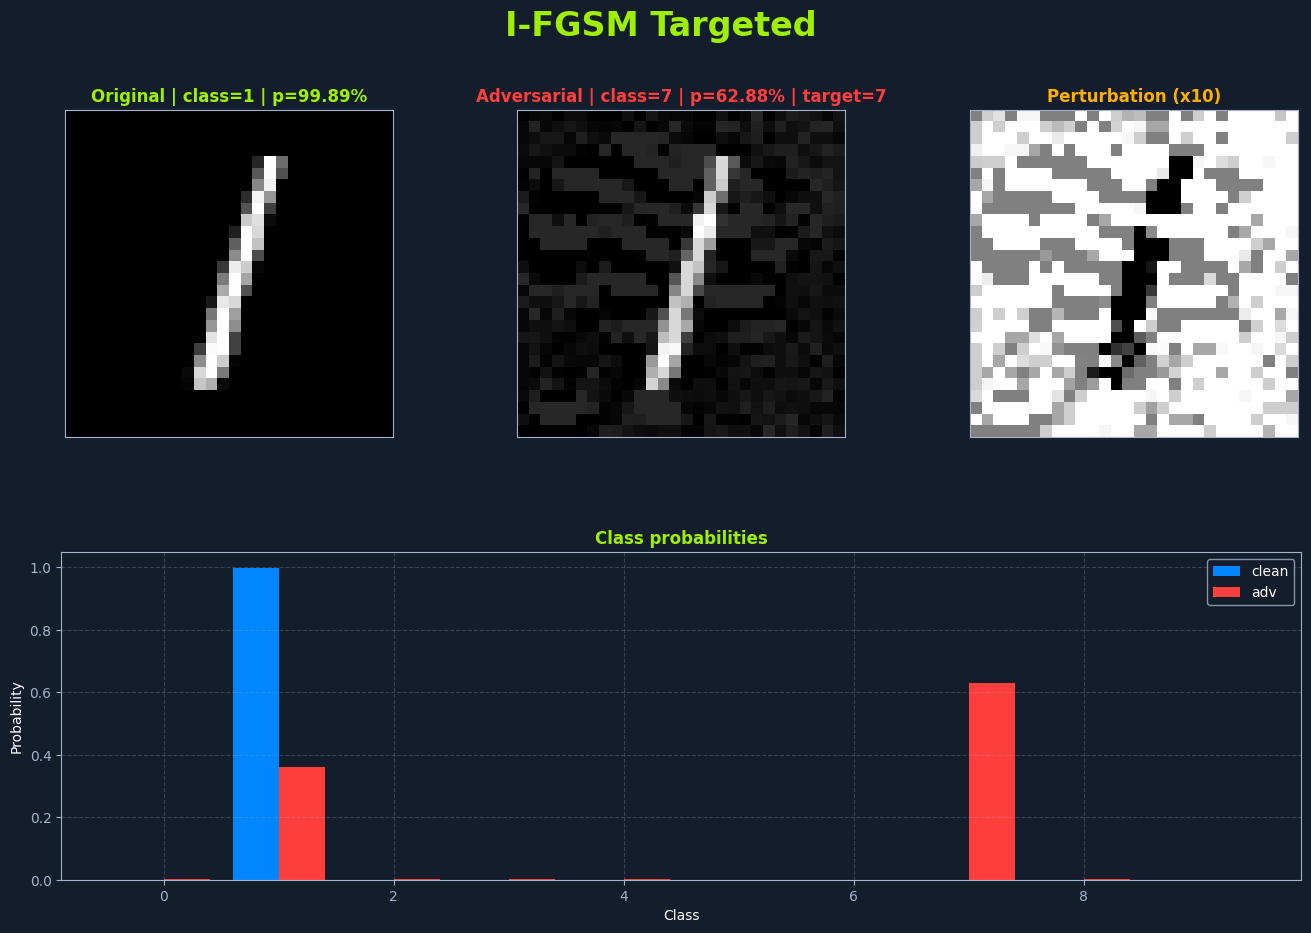

In [39]:
###################################################
# HERE STARTS TARGETTED
###################################################



# Find one sample of '1'
one_img, one_lbl = None, None
for xb, yb in test_loader:
    m = (yb == 1)
    if m.any():
        j = m.nonzero(as_tuple=True)[0][0].item()
        one_img = xb[j].to(device)
        one_lbl = yb[j].to(device)
        break

# Try increasing epsilon values until successful
for eps_try in [0.5, 0.8, 1.0]:
    x_adv = iterative_fgsm(
        model,
        one_img.unsqueeze(0),
        torch.tensor(7, device=device).unsqueeze(0),  # target label
        epsilon=eps_try,
        num_iter=num_iter,
        alpha=eps_try / max(num_iter, 1),
        targeted=True,
        random_start=True,
    )
    with torch.no_grad():
        pred = model(x_adv).argmax(dim=1).item()
    print(f"epsilon={eps_try:.2f} -> predicted {pred}")

    if pred == 7:
        _ = visualize_ifgsm(
            model,
            one_img.detach().cpu(),
            one_lbl.detach().cpu(),
            eps_try,
            num_iter,
            targeted=True,
            target_class=7,
        )
        break


In [40]:
###############################################
# COMPARE FGSM VS IFGSM
###############################################

# Compare FGSM (one-step) and I-FGSM on the same batch
# Run both attacks with same epsilon
epsilon = 0.7
x_adv_fgsm = fgsm_attack(model, images, labels, epsilon)
x_adv_ifgsm = iterative_fgsm(
    model, images, labels,
    epsilon, num_iter=10,
    random_start=True
)

# Compare success rates
with torch.no_grad():
    fgsm_pred = model(x_adv_fgsm).argmax(dim=1)
    ifgsm_pred = model(x_adv_ifgsm).argmax(dim=1)

orig_correct = clean_pred == labels
fgsm_success = (
    ((fgsm_pred != labels) & orig_correct).float().sum()
    / orig_correct.float().sum().clamp_min(1.0)
)
ifgsm_success = (
    ((ifgsm_pred != labels) & orig_correct).float().sum()
    / orig_correct.float().sum().clamp_min(1.0)
)

print(f"FGSM success rate: {fgsm_success:.1%}")
print(f"I-FGSM success rate: {ifgsm_success:.1%}")
print(f"Improvement: {(ifgsm_success - fgsm_success) / fgsm_success:.1%}")

FGSM success rate: 54.7%
I-FGSM success rate: 95.3%
Improvement: 74.3%
